In [1]:
# from sklearn.model_selection import train_test_split
# import pandas as pd
# from sklearn.svm import SVR
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import r2_score
# from sklearn import datasets

In [2]:
# df = datasets.load_diabetes(as_frame = True).frame

In [4]:
# X = df.drop("target",axis = 1)
# y = df["target"]

In [5]:
# X_train,X_test,y_train,y_test = train_test_split(
#     X,y,test_size = 0.3,random_state = 42
# )

In [6]:
# y_scaled = StandardScaler()

# y_train_scaled = y_scaled.fit_transform(y_train.values.reshape(-1,1)).ravel()
# y_test_scaled = y_scaled.transform(y_test.values.reshape(-1,1)).ravel()


In [7]:
# model = SVR()

# model.fit(X_train,y_train_scaled)


In [8]:
# y_test_pred_scaled = model.predict(X_test)
# y_train_pred_scaled = model.predict(X_train)

# print("r2 score : ",r2_score(y_train_scaled,y_train_pred_scaled))
# print("r2 score : ",r2_score(y_test_scaled,y_test_pred_scaled))


In [9]:
# model = SVR(kernel="linear")

# model.fit(X_train,y_train_scaled)

# y_test_pred_scaled = model.predict(X_test)
# y_train_pred_scaled = model.predict(X_train)

# print("r2 score : ",r2_score(y_train_scaled,y_train_pred_scaled))
# print("r2 score : ",r2_score(y_test_scaled,y_test_pred_scaled))

In [10]:
# model = SVR(kernel="poly")

# model.fit(X_train,y_train_scaled)

# y_test_pred_scaled = model.predict(X_test)
# y_train_pred_scaled = model.predict(X_train)

# print("r2 score : ",r2_score(y_train_scaled,y_train_pred_scaled))
# print("r2 score : ",r2_score(y_test_scaled,y_test_pred_scaled))

In [11]:
# model = SVR(kernel="sigmoid")

# model.fit(X_train,y_train_scaled)

# y_test_pred_scaled = model.predict(X_test)
# y_train_pred_scaled = model.predict(X_train)

# print("r2 score : ",r2_score(y_train_scaled,y_train_pred_scaled))
# print("r2 score : ",r2_score(y_test_scaled,y_test_pred_scaled))

Hyparameter tuning using GridSearchCV

In [12]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     "C":[1,2,5,10,50,100],
#     "kernel":["rbf","linear"],
#     "epsilon":[0.01,0.1,0.2,0.3,0.5]
# }

In [13]:
# svr = SVR()
# grid_search = GridSearchCV(svr,param_grid,scoring="r2",cv =5)
# grid_search.fit(X_train,y_train_scaled)

In [14]:
# print(grid_search.best_params_)

In [15]:
# best_model = SVR(kernel='linear',C=10,epsilon=0.1)

# best_model.fit(X_train,y_train_scaled)

# y_test_pred_scaled = best_model.predict(X_test)
# y_train_pred_scaled = best_model.predict(X_train)

# print("r2 score : ",r2_score(y_train_scaled,y_train_pred_scaled))
# print("r2 score : ",r2_score(y_test_scaled,y_test_pred_scaled))

In [16]:
# from sklearn.svm import LinearSVR

# model = LinearSVR(C=10,epsilon=0.1,max_iter = 3000)

# model.fit(X_train,y_train_scaled)

# y_test_pred_scaled = model.predict(X_test)
# y_train_pred_scaled = model.predict(X_train)

# print("r2 score : ",r2_score(y_train_scaled,y_train_pred_scaled))
# print("r2 score : ",r2_score(y_test_scaled,y_test_pred_scaled))

In [17]:
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier 

In [18]:
titanic = sns.load_dataset("titanic")

features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic["survived"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 42
)

In [19]:
model = DecisionTreeClassifier()

model.fit(X_train,y_train)
y_pred_test = model.predict(X_test)
y_train_pred = model.predict(X_train)

print("Training accuracy : ",accuracy_score(y_train,y_train_pred))
print("Testing accuracy : ",accuracy_score(y_test,y_pred_test))

Training accuracy :  0.9775280898876404
Testing accuracy :  0.776536312849162


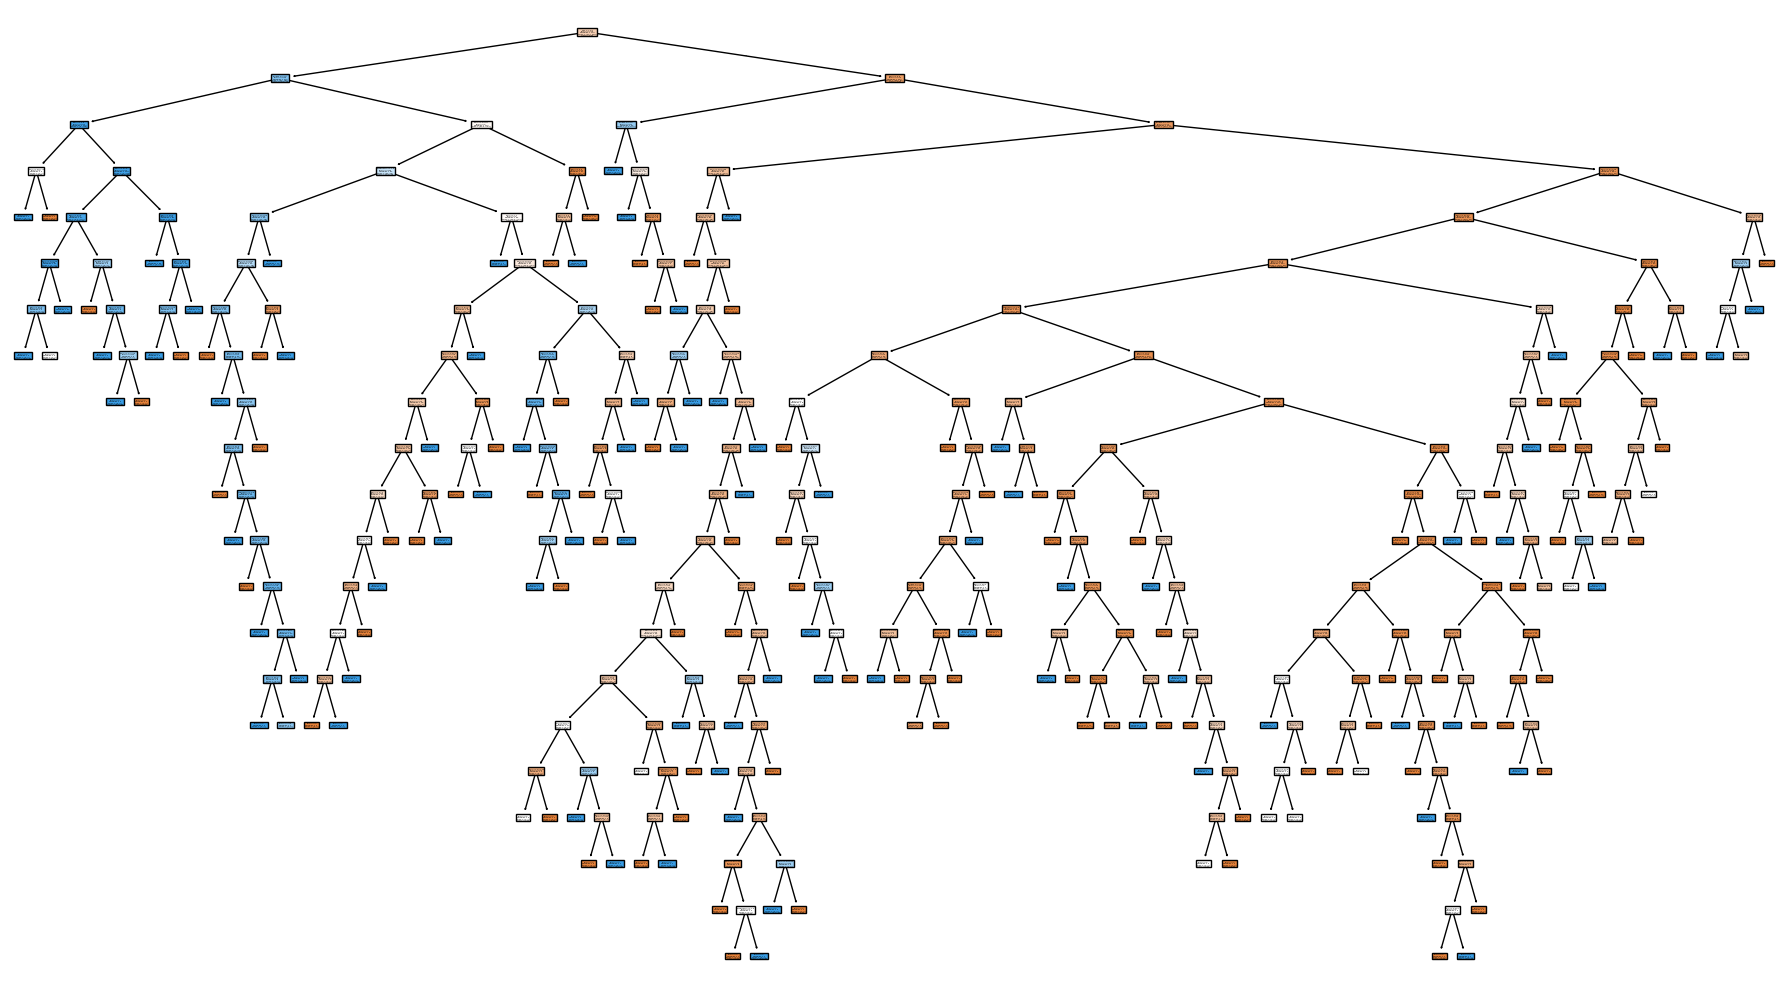

In [20]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True
)

plt.tight_layout()
plt.show()

In [24]:
#random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=301, 
    oob_score=True
)

rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

print("accuracy score : ",accuracy_score(y_test,y_pred)*100,"%")
print("OOB Score : ",rf.oob_score_*100,"%")

accuracy score :  81.00558659217877 %
OOB Score :  79.91573033707866 %
